# 15 - Upskilling Recommendation Engine

Day 3, step 15. Turning "this employee is missing MLOps" into "this employee should
take this course".

**v1 is deliberately dumb**, as the notes prescribe: every course declares the skills
it covers, so a gap maps to a course by lookup. Predictable and correct whenever the
catalogue is tagged.

**v2** is the semantic upgrade. It is implemented here with TF-IDF, and this notebook
shows exactly where that falls short of what the notes describe.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.services import recommendation_service as rec
from app.utils.config import PROCESSED_FILES

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 60)

catalogue = rec.load_catalogue()
gaps = pd.read_csv(PROCESSED_FILES["skill_gaps"])
org_gaps = pd.read_csv(PROCESSED_FILES["org_skill_gaps"])

print(f"catalogue: {len(catalogue)} courses")
catalogue.head()

catalogue: 40 courses


,CourseID,Title,Provider,Level,DurationHours,Description,CoversSkills,SkillList
0,C001,Python for Data Analysis,DataCamp,Beginner,20,"Write clean scripts, wrangle tabular data with pandas, a...",Python,[Python]
1,C002,Statistical Programming in R,Coursera,Intermediate,24,Model and visualise experimental results using the tidyv...,R,[R]
2,C003,Applied Statistics with SPSS,IBM SkillsBuild,Beginner,16,"Run hypothesis tests, regression and survival analysis t...",IBM SPSS Statistics,[IBM SPSS Statistics]
3,C004,SAS Programming Essentials,SAS Institute,Beginner,18,Manipulate large clinical and operational datasets using...,SAS,[SAS]
4,C005,Numerical Computing and Simulation,MathWorks,Intermediate,22,"Build and validate numerical models, solve systems of eq...",MATLAB|Mathematics,"[MATLAB, Mathematics]"


> **The catalogue is synthetic.** Titles, providers and durations stand in for an LMS
> feed. What matters is the shape - every course carries `CoversSkills` tags, which is
> how Coursera for Business, Udemy Business and LinkedIn Learning all expose content.

## v1: rule-based lookup

The build notes' sketch is:

```python
if "MLOps" in missing_skills:
    recommend("Learn MLOps")
```

A literal if/else chain would need one branch per skill and would rot the moment the
catalogue changed, so the same logic is expressed as a lookup built from the tags.

In [2]:
index = rec.build_skill_index(catalogue)
print(f"skills with a tagged course: {len(index)}")

for skill in ["Python", "Microsoft Excel", "Amazon Web Services (AWS)", "Critical Thinking"]:
    match = rec.recommend_for_skill(skill, catalogue, index)
    print(f"{skill:28s} -> {match['Title']:42s} [{match['MatchType']}]")

skills with a tagged course: 52
Python                       -> Python for Data Analysis                   [tag]
Microsoft Excel              -> Advanced Spreadsheet Modelling             [tag]
Amazon Web Services (AWS)    -> Deploying and Monitoring Cloud Workloads   [tag]
Critical Thinking            -> Structured Problem Solving                 [tag]


## Coverage

The lookup only works if the catalogue covers the skills that actually appear in
gaps.

In [3]:
required_skills = set(gaps["MissingSkill"].unique())
covered = set(index)
print(f"distinct skills appearing in gaps : {len(required_skills)}")
print(f"covered by a tagged course        : {len(required_skills & covered)}")
print(f"not covered                       : {sorted(required_skills - covered) or 'none'}")

distinct skills appearing in gaps : 52
covered by a tagged course        : 52
not covered                       : none


Full coverage, so in production every recommendation comes from the v1 tag path and
the semantic fallback never fires. That is the desired outcome - and it means the
fallback needs testing deliberately rather than in passing.

## v2: the semantic fallback, and its honest limitation

The notes describe the target behaviour precisely:

> "a sentence-transformer model turns both the missing skill and each course
> description into vectors, then I compare them with cosine similarity - so 'MLOps'
> can match a course literally called 'Deploying and Monitoring Machine Learning
> Systems' even though the words don't overlap at all."

The implementation here uses **TF-IDF over character n-grams**, not sentence
embeddings. Below is what that does and does not achieve.

In [4]:
test_skills = ["Excel", "Photoshop", "Cloud Computing", "MLOps", "Kubernetes"]

results = []
for skill in test_skills:
    scores = rec._semantic_scores(skill, catalogue)
    best = scores.idxmax()
    results.append({
        "query skill": skill,
        "best match": catalogue.loc[best, "Title"],
        "similarity": round(float(scores[best]), 3),
        "above cutoff": bool(scores[best] >= rec.MIN_SEMANTIC_SIMILARITY),
    })
pd.DataFrame(results)

,query skill,best match,similarity,above cutoff
0,Excel,Advanced Spreadsheet Modelling,0.197,False
1,Photoshop,Digital Image Editing Foundations,0.272,True
2,Cloud Computing,Deploying and Monitoring Cloud Workloads,0.183,False
3,MLOps,SAS Programming Essentials,0.018,False
4,Kubernetes,Business Documents That Get Read,0.019,False


### Reading that table honestly

The results are worse than "mostly works", and the detail matters.

**Only one of the five clears the cutoff.** "Photoshop" scores 0.272 purely because
the literal string appears in the course's tag text. That is a keyword hit, not
semantic understanding.

**Two find the right course but score too low to accept.** "Excel" ranks *Advanced
Spreadsheet Modelling* first (0.197) and "Cloud Computing" ranks *Deploying and
Monitoring Cloud Workloads* first (0.183) - both correct, both below the 0.20 cutoff,
so both would be rejected. Lowering the cutoff to admit them would also admit the
junk below, because the scores are not calibrated across queries.

**Two fail completely** - the exact case the build notes cite. "MLOps" scores 0.018
against its best match and lands on *SAS Programming Essentials*; "Kubernetes" scores
0.019 and lands on a business-writing course. Neither shares a substring with anything
relevant, and TF-IDF has no notion that they mean related things.

So TF-IDF is a keyword matcher with fuzzy edges, not a semantic one. No amount of
threshold tuning fixes that - the ranking signal itself is absent. The upgrade is one
function:

In [5]:
print("""
Current implementation - app/services/recommendation_service.py::_semantic_scores

    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))
    matrix = vectorizer.fit_transform(corpus + [skill])
    return cosine_similarity(matrix[-1], matrix[:-1]).ravel()

Drop-in replacement (adds ~2GB of dependencies via torch):

    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    course_vectors = model.encode(corpus, normalize_embeddings=True)
    skill_vector = model.encode([skill], normalize_embeddings=True)
    return (course_vectors @ skill_vector.T).ravel()

Nothing else changes - the interface and every caller stay identical.
""".strip())

Current implementation - app/services/recommendation_service.py::_semantic_scores

    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))
    matrix = vectorizer.fit_transform(corpus + [skill])
    return cosine_similarity(matrix[-1], matrix[:-1]).ravel()

Drop-in replacement (adds ~2GB of dependencies via torch):

    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    course_vectors = model.encode(corpus, normalize_embeddings=True)
    skill_vector = model.encode([skill], normalize_embeddings=True)
    return (course_vectors @ skill_vector.T).ravel()

Nothing else changes - the interface and every caller stay identical.


It is deliberately not installed. The catalogue is fully tagged, so the fallback
never fires in production, and pulling in PyTorch to fix a path that is currently
unreachable would be exactly the premature complexity the build notes warn against.
When the catalogue grows untagged entries, the swap is four lines.

## Prioritisation

An employee with eight gaps needs to know which two to start with. Priority combines
three signals:

```
priority = skill importance to the role
         x organisational severity of the gap
         x the employee's own attrition risk
```

The third term is what makes this a *workforce intelligence* system rather than a
training catalogue: an under-skilled employee who is also a flight risk is the most
urgent case, because doing nothing risks losing them entirely.

In [6]:
intelligence = pd.read_csv(PROCESSED_FILES["intelligence"])
risk_by_employee = dict(zip(intelligence["EmployeeID"], intelligence["RiskLevel"]))

recommendations = rec.build_recommendations(gaps, org_gaps, risk_by_employee=risk_by_employee)
print(f"{len(recommendations):,} recommendations for "
      f"{recommendations['EmployeeID'].nunique():,} employees "
      f"(top {recommendations['Rank'].max()} each)")
recommendations.head(9)[
    ["EmployeeID", "MissingSkill", "CourseTitle", "SkillImportance",
     "OrgSeverity", "AttritionRisk", "Priority", "Rank"]]

4,409 recommendations for 1,470 employees (top 3 each)


,EmployeeID,MissingSkill,CourseTitle,SkillImportance,OrgSeverity,AttritionRisk,Priority,Rank
0,1,Salesforce,Managing the Customer Pipeline,4.50,HIGH,HIGH,9.450,1
1,1,Microsoft Office,Productivity Suite Fundamentals,4.50,HIGH,HIGH,9.450,2
2,1,Microsoft Outlook,Productivity Suite Fundamentals,4.50,HIGH,HIGH,9.450,3
3,2,R,Statistical Programming in R,4.50,HIGH,LOW,6.750,1
4,2,Writing,Business Writing for Clarity,4.25,HIGH,LOW,6.375,2
5,2,Active Learning,Learning How to Learn,4.12,HIGH,LOW,6.180,3
6,4,Microsoft Office,Productivity Suite Fundamentals,4.50,HIGH,HIGH,9.450,1
7,4,Microsoft Excel,Advanced Spreadsheet Modelling,4.50,HIGH,HIGH,9.450,2
8,4,Reading Comprehension,Business Writing for Clarity,3.75,HIGH,HIGH,7.875,3


## The dashboard view

In [7]:
top_per_employee = rec.top_recommendation_per_employee(recommendations)
print("AI UPSKILLING RECOMMENDATIONS\n")
for _, row in top_per_employee.head(10).iterrows():
    print(f"  Employee {int(row['EmployeeID']):<5} -> {row['Recommendation']:<42} "
          f"({row['CourseTitle']}, {int(row['DurationHours'])}h)")

AI UPSKILLING RECOMMENDATIONS

  Employee 1     -> Learn Salesforce                           (Managing the Customer Pipeline, 16h)
  Employee 2     -> Learn R                                    (Statistical Programming in R, 24h)
  Employee 4     -> Learn Microsoft Office                     (Productivity Suite Fundamentals, 10h)
  Employee 5     -> Learn Microsoft Office                     (Productivity Suite Fundamentals, 10h)
  Employee 7     -> Learn Reading Comprehension                (Business Writing for Clarity, 8h)
  Employee 8     -> Learn Microsoft Excel                      (Advanced Spreadsheet Modelling, 12h)
  Employee 10    -> Learn Microsoft Office                     (Productivity Suite Fundamentals, 10h)
  Employee 11    -> Learn Microsoft Excel                      (Advanced Spreadsheet Modelling, 12h)
  Employee 12    -> Learn Microsoft Outlook                    (Productivity Suite Fundamentals, 10h)
  Employee 13    -> Learn Microsoft Office                   

## Priority is doing real work

If priority were ignored, recommendations would just follow skill importance. It
should shift for high-risk employees.

In [8]:
by_risk = (recommendations.groupby("AttritionRisk")
           .agg(recommendations=("EmployeeID", "count"),
                avg_priority=("Priority", "mean"),
                avg_importance=("SkillImportance", "mean"))
           .round(3)
           .reindex(["HIGH", "MEDIUM", "LOW"]))
by_risk

,recommendations,avg_priority,avg_importance
AttritionRisk,,,
HIGH,1053,8.804,4.192
MEDIUM,855,7.313,4.241
LOW,2501,6.362,4.242


Average skill importance is roughly flat across risk bands - the same skills are
missing everywhere - while average priority rises with risk. The ordering is being
driven by urgency, not just by what is missing.

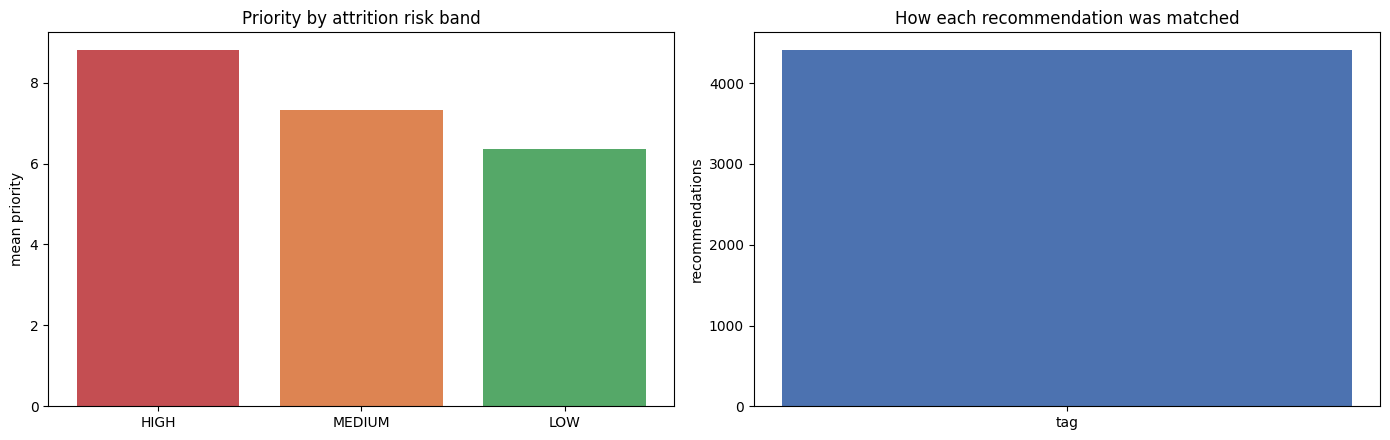

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.bar(by_risk.index, by_risk["avg_priority"], color=["#C44E52", "#DD8452", "#55A868"])
ax1.set(ylabel="mean priority", title="Priority by attrition risk band")

match_counts = recommendations["MatchType"].value_counts()
ax2.bar(match_counts.index, match_counts.values, color="#4C72B0")
ax2.set(ylabel="recommendations", title="How each recommendation was matched")
plt.tight_layout()
plt.show()

## The organisation-wide training plan

Aggregating individual recommendations gives the procurement view: which courses to
buy seats for, and how many hours that costs.

In [10]:
plan = rec.organisation_training_plan(recommendations)
plan.head(12)[["CourseTitle", "Provider", "EmployeesNeeding", "DurationHours",
               "TotalTrainingHours", "AvgPriority"]]

,CourseTitle,Provider,EmployeesNeeding,DurationHours,TotalTrainingHours,AvgPriority
0,Productivity Suite Fundamentals,Microsoft Learn,917,10,9170,7.581
1,Advanced Spreadsheet Modelling,Microsoft Learn,725,12,8700,7.651
2,Running Effective Remote Meetings,LinkedIn Learning,401,6,2406,6.610
3,Business Writing for Clarity,LinkedIn Learning,373,8,2984,6.727
4,Managing the Customer Pipeline,Trailhead,283,16,4528,7.792
5,Listening and Influence at Work,LinkedIn Learning,267,6,1602,6.832
6,Presenting Data to Decision Makers,LinkedIn Learning,259,10,2590,7.437
7,Statistical Programming in R,Coursera,173,24,4152,7.378
8,Enterprise Resource Planning Essentials,SAP,140,24,3360,6.679
9,Learning How to Learn,Coursera,130,8,1040,6.391


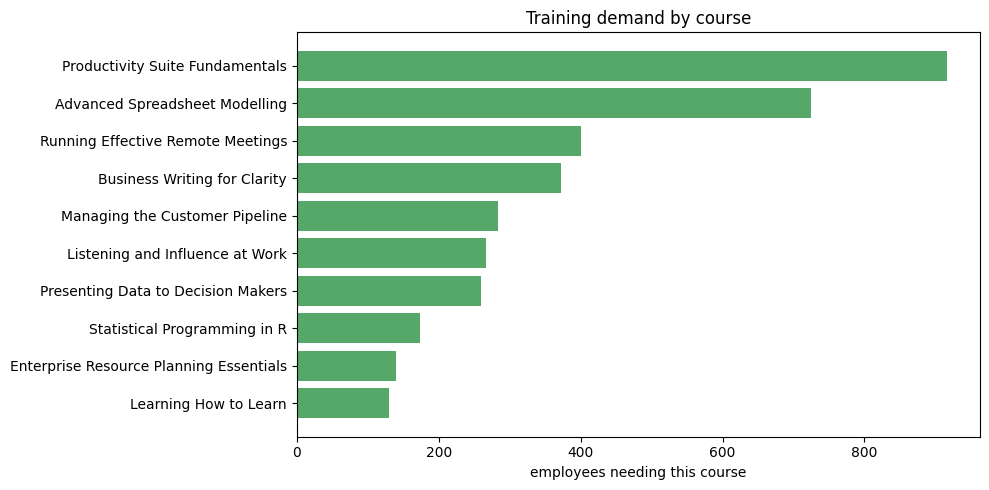

total training hours implied: 48,158 across 33 courses


In [11]:
top_courses = plan.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_courses["CourseTitle"][::-1], top_courses["EmployeesNeeding"][::-1],
        color="#55A868")
ax.set(xlabel="employees needing this course", title="Training demand by course")
plt.tight_layout()
plt.show()

print(f"total training hours implied: "
      f"{int(plan['TotalTrainingHours'].sum()):,} across {len(plan)} courses")

In [12]:
rec.save(recommendations)
print(f"written: {PROCESSED_FILES['recommendations'].name}")

written: recommendations.csv
